In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
# Directory = r'D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing'
# os.chdir(Directory)
pwd = os.getcwd()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

# ----------------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------------
WorkDir   = Path().resolve()       # D:\...\scripts\directional_coupler
REPO_ROOT = WorkDir.parents[1]     # D:\Ligentic_NU_1_TapeOut_April2026
os.chdir(WorkDir)

DataDir = WorkDir / "results_data" / "RingMOD_Ligentec_Results"
DataDir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WorkDir)
print("Data save   :", DataDir)

Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing\results_data\RingMOD_Ligentec_Results


In [2]:
neff = 1.7780
L = 2 * np.pi * 50E-6 
lambda0 = 1550E-9

M = int(neff * L / lambda0)
print("M =", M)

M = 360


In [3]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'RingMOD_Ligentec_test.lms' # save .lms file
f.save(LumFileName)
f.switchtolayout()
f.selectall()
f.delete()
f.switchtolayout()

Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [4]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart    = 1540E-9
LambdaStop     = 1560E-9

WidthIO        = 1000E-9
Width          = 1200E-9  
Height         = 800E-9
Radius         = 50E-6
Gap            = 800E-9
Length         = 4 * Radius
# Material       = "Si3N4 (Silicon Nitride) - Luke"
Material       ="<Object defined dielectric>"
CouplingLength = 0.0E-6
use_index      = True
Index          = 1.97; #optional
decay_time     = 1E-6

BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 100E-12
# FrequencyPoints    = 2*10000; #for monitors 
FrequencyPoints    = round(5000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 100000


Mode numbers: [360]
Relative μ: [0]
Amplitudes (nm): [15.]
Minimum radius: 1.19 µm
Maximum radius: 1.22 µm
Ring Area: 372.47 µm²
Modulated Ring Area: 372.47 µm²
Area Difference due to modulation: -0.00 µm²


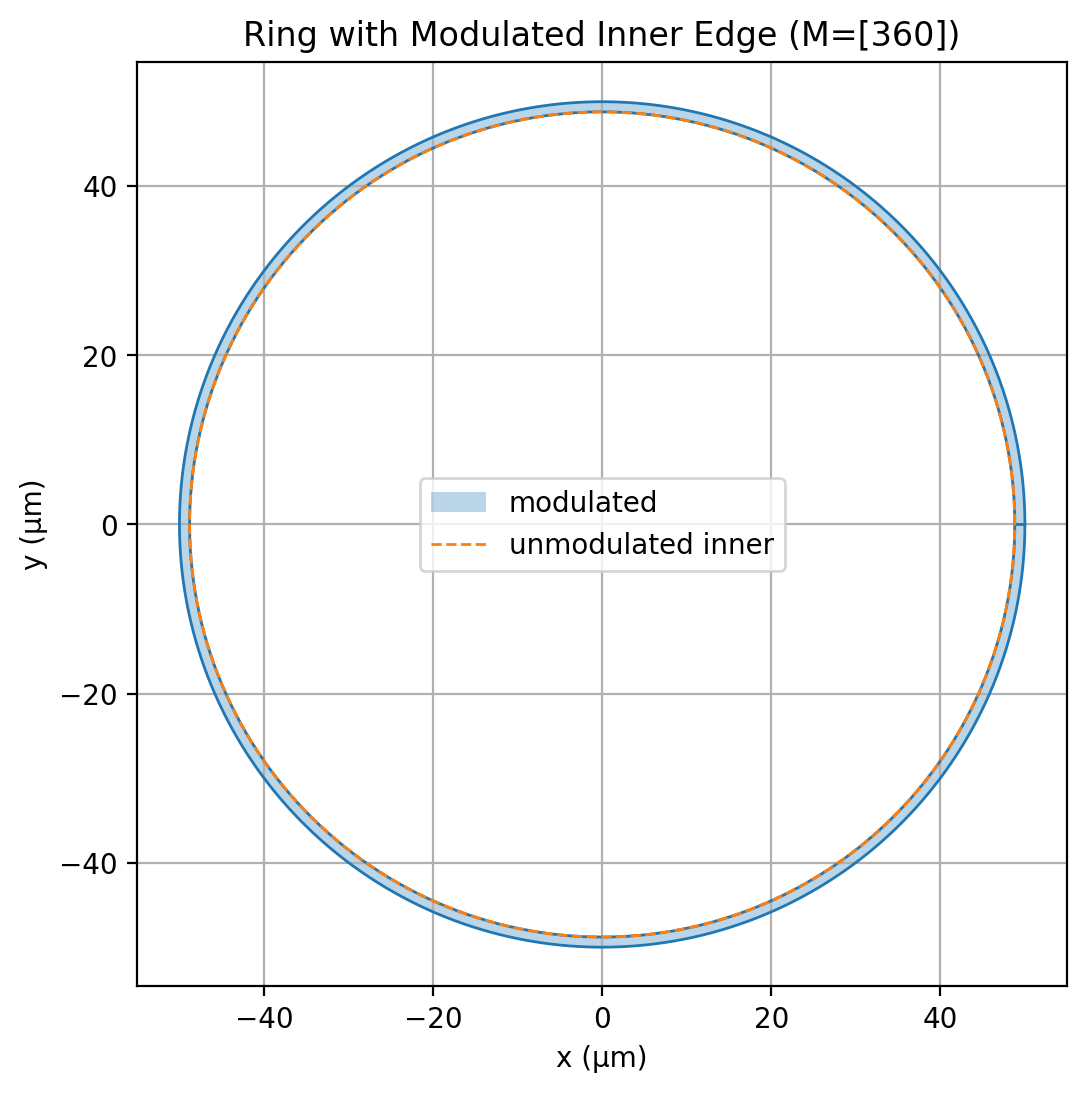

Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.


In [5]:
# --- Mode number tracking ---------------

# M_ref = 371 # Mode numbers (using 300 as reference μ=0)
M_ref = 360
# M     = np.array(np.linspace(370,373,2))
# M = [377,376,375,374,373,368,367,366]  # Mode numbers to be modulated
M = [360]  # Mode numbers to be modulated
mu    = np.array(M) - M_ref  # Relative mode numbers: [1, 2, 5, 10, 20]
print(f"Mode numbers: {M}")
print(f"Relative μ: {mu}")

# --- Amplitude of modulation ---------------

A_max = 15E-9
# A = A_max*(abs(mu)/np.max(mu))**2  # Amplitude of modulation
A = A_max*np.ones_like(mu)     # Amplitude of modulation
print(f"Amplitudes (nm): {A*1e9}")
Npoints = max(5000, 300*M_ref)  # Number of points for smoothness

#--- Modulated Ring Generation --------------

def generate_inner_modulated_ring(Radius=4e-6,
                                    width=700e-9,
                                    A=300e-9,
                                    M=50,
                                    Npoints=1000):
    theta         = np.linspace(0, 2*np.pi, Npoints)
    R_inner_base  = Radius - width
    R_outer_base  = Radius 

    # ensure A_list, M_list
    A_list = np.atleast_1d(A)
    M_list = np.atleast_1d(M)

    # sum of cosines
    modulation = np.zeros_like(theta)
    for i, (Ai, Mi) in enumerate(zip(A_list, M_list)):
        
        if Mi == 0:
            # No modulation for M=0
            modulation += Ai
        else:
            # Normalized modulation
            # modulation += Ai * (np.cos(2*Mi * theta + (2*np.pi/ (i+1))))
            modulation += Ai * np.cos(2*Mi * theta + (2*np.pi/len(M_list))*i)

    R_inner       = R_inner_base - modulation
    R_outer_const = R_outer_base
    
    min_radius = np.min(R_outer_const-R_inner)
    print(f"Minimum radius: {min_radius*1e6:.2f} µm")
    
    max_radius = np.max(R_outer_const-R_inner)
    print(f"Maximum radius: {max_radius*1e6:.2f} µm")

    RingArea = np.pi * (R_outer_const**2 - R_inner_base**2)
    print(f"Ring Area: {RingArea*1e12:.2f} µm²")
    
    ModRingArea = np.pi * (R_outer_const**2 - np.mean(R_inner**2))
    print(f"Modulated Ring Area: {ModRingArea*1e12:.2f} µm²")
    
    AreaDiff = ModRingArea - RingArea
    print(f"Area Difference due to modulation: {AreaDiff*1e12:.2f} µm²")

    x_inner = R_inner * np.cos(theta)
    y_inner = R_inner * np.sin(theta)
    x_outer = R_outer_const * np.cos(theta[::-1])
    y_outer = R_outer_const * np.sin(theta[::-1])

    x_poly = np.concatenate([x_inner, x_outer])
    y_poly = np.concatenate([y_inner, y_outer])
    return x_poly, y_poly

x_poly, y_poly = generate_inner_modulated_ring(Radius=Radius ,
                                            width=Width, A = A, M=M, Npoints=Npoints)
# compute unmodulated inner ring
theta_base   = np.linspace(0, 2*np.pi, Npoints)
R_inner_base = Radius - Width  
x_base       = R_inner_base * np.cos(theta_base)
y_base       = R_inner_base * np.sin(theta_base)

# visualize
plt.figure(figsize=(6,6))
plt.fill(x_poly*1e6, y_poly*1e6, alpha=0.3, label='modulated')
plt.plot(x_poly*1e6, y_poly*1e6, '-', linewidth=1)
plt.plot(x_base*1e6, y_base*1e6, '--', linewidth=1, label='unmodulated inner')
plt.axis('equal')
plt.gcf().set_dpi(200)
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title(f'Ring with Modulated Inner Edge (M={M})')
plt.legend()
plt.grid()

# Save figure as high-res PNG for zooming in
plt.savefig("modulated_ring_zoom.png", dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.")

In [6]:
#------------------------------------------------------------
# STRUCTURE GROUP : Ring 
#------------------------------------------------------------

group_name = "Ring Resonator Group"
f.addstructuregroup()
f.set("name", group_name)
f.set("construction group", 1)
f.set("x",0)
f.set("y",0)
f.set("z",0)

# ADD USER PROPERTIES (keep original ones only)
f.adduserprop("Width",          2, Width)
f.adduserprop("WidthIO",        2, WidthIO)
f.adduserprop("Height",         2, Height)
f.adduserprop("Radius",         2, Radius)
f.adduserprop("Gap",            2, Gap)
f.adduserprop("Length",         2, Length)
f.adduserprop("Material",       5, Material)
f.adduserprop("Index",          0, Index)
f.adduserprop("CouplingLength", 2, CouplingLength)

# Convert vertices to Lumerical matrix format
vertices_str = "["
for i in range(len(x_poly)):
    vertices_str += f"{x_poly[i]}, {y_poly[i]};"
vertices_str = vertices_str.rstrip(';') + "]"

#------------------------------------------------------------
# GEOMETRY SETUP SCRIPT
#------------------------------------------------------------

setup_script = f"""
# Base waveguides
addrect;
set('name','WG1');
set('x', 0);
set('x span', Length);
set('y span', WidthIO);
set('y', Radius + Gap + WidthIO/2);
copy(0, -2 * (Radius + Gap + WidthIO/2), 0);

# Modulated Ring using polygon vertices
addpoly;
set('name', 'modulated_ring');
set('vertices', {vertices_str});

# Assign materials & finalize structure
selectall;
set('material', Material);
if (Material == '<Object defined dielectric>') {{
    set('index', Index);
}}
set('z min', 0);
set('z max', Height);
"""

f.set("script", setup_script)

In [7]:
#------------------------------------------------------------
# VarFDTD
#------------------------------------------------------------

f.addvarfdtd()
f.set("simulation time", SimulationTime) 
f.set("x0", Width/2-Radius-CouplingLength/2)              # mode position (that green arrow)
f.set("y0",0)
# f.set("y0", Radius + Gap + Width)
f.set("x", 0)                    # Centered in X
f.set("x span", 2.5 * Radius + CouplingLength/2)    # Cover full structure
f.set("y", 0)                    # Centered in Y
f.set("y span", 2.5 * (Radius + Gap + Width))  # Cover full waveguide & ring
f.set("z", Height / 2)           # Centered in Z
f.set("z span", 8*Height)        # Cover height of the structure
f.set("background material",BackgroundMaterial)
f.set("set simulation bandwidth",1)
f.set("bandwidth",'broadband')
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min",decay_time)

# Boundary Conditions
f.set("x min bc", "PML")
f.set("x max bc", "PML")
f.set("y min bc", "PML")
f.set("y max bc", "PML")
f.set("z min bc", "PML")
f.set("z max bc", "PML")

# TEST POINT POSITIONS (Blue Arrows) - On the Arc
theta = [45, 135, 225, 315]   # Angles for test points (degrees)
test_points = np.zeros((2, 4))  # Creates a 2-row, 4-column matrix for (x, y) coordinates

for i in range(4):
    angle_rad = theta[i] * np.pi / 180  # Convert degrees to radians
    test_points[0, i] = Radius * np.cos(angle_rad)  # x-coordinate
    test_points[1, i] = Radius * np.sin(angle_rad)  # y-coordinate

f.set("test points", test_points)

#------------------------------------------------------------
# Source
#------------------------------------------------------------

# f.addmodesource()
# f.set("name", "ModeSource")
# f.set("x", -Radius-CouplingLength/2)
# f.set("y", Radius + Gap + Width/2)
# f.set("y span", 2 * Width)
# f.set("use relative coordinates", 1)
# f.set("injection axis", "x-axis")
# f.set("direction", "Forward")
# f.set("amplitude", 1.0)
# f.set("phase", 0)
# f.set("mode selection", "fundamental mode")
# f.set("set wavelength", 1)
# f.set("wavelength start", LambdaStart)
# f.set("wavelength stop", LambdaStop)

f.addplane()
f.set("name", "PlaneWaveSource")
f.set("injection axis", "x-axis")
f.set("x", -Radius-CouplingLength/2)
f.set("y", Radius + Gap + Width/2)
f.set("y span", Width)
f.set("use relative coordinates", 1)
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)

#------------------------------------------------------------
# Monitors 
#------------------------------------------------------------

# THROUGH PORT
f.adddftmonitor()
f.set("name", "Through")
f.set("monitor type", "Linear Y")
f.set("x", Radius+CouplingLength/2)
f.set("y", Radius + Gap + WidthIO/2)
f.set("y span", 2 * WidthIO)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)
f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)

# DROP PORT
f.adddftmonitor()
f.set("name", "Drop")
f.set("monitor type", "Linear Y")
f.set("x", -Radius-CouplingLength/2)
f.set("y", -(Radius + Gap + WidthIO/2))
f.set("y span", 2 * WidthIO)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)
f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)

In [8]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------
f.run()

Wavelength range: 1560.00 nm to 1540.00 nm
Peaks: [1557.53058137 1554.91920022 1553.5910701  1549.67543573 1546.99088204
 1545.78167765 1541.91060449]
Summary of results at 1550 nm:
-----------------------------------
Drop Efficiency at 1550 nm: 0.79 %
Drop Loss at 1550 nm: 21.01 dB


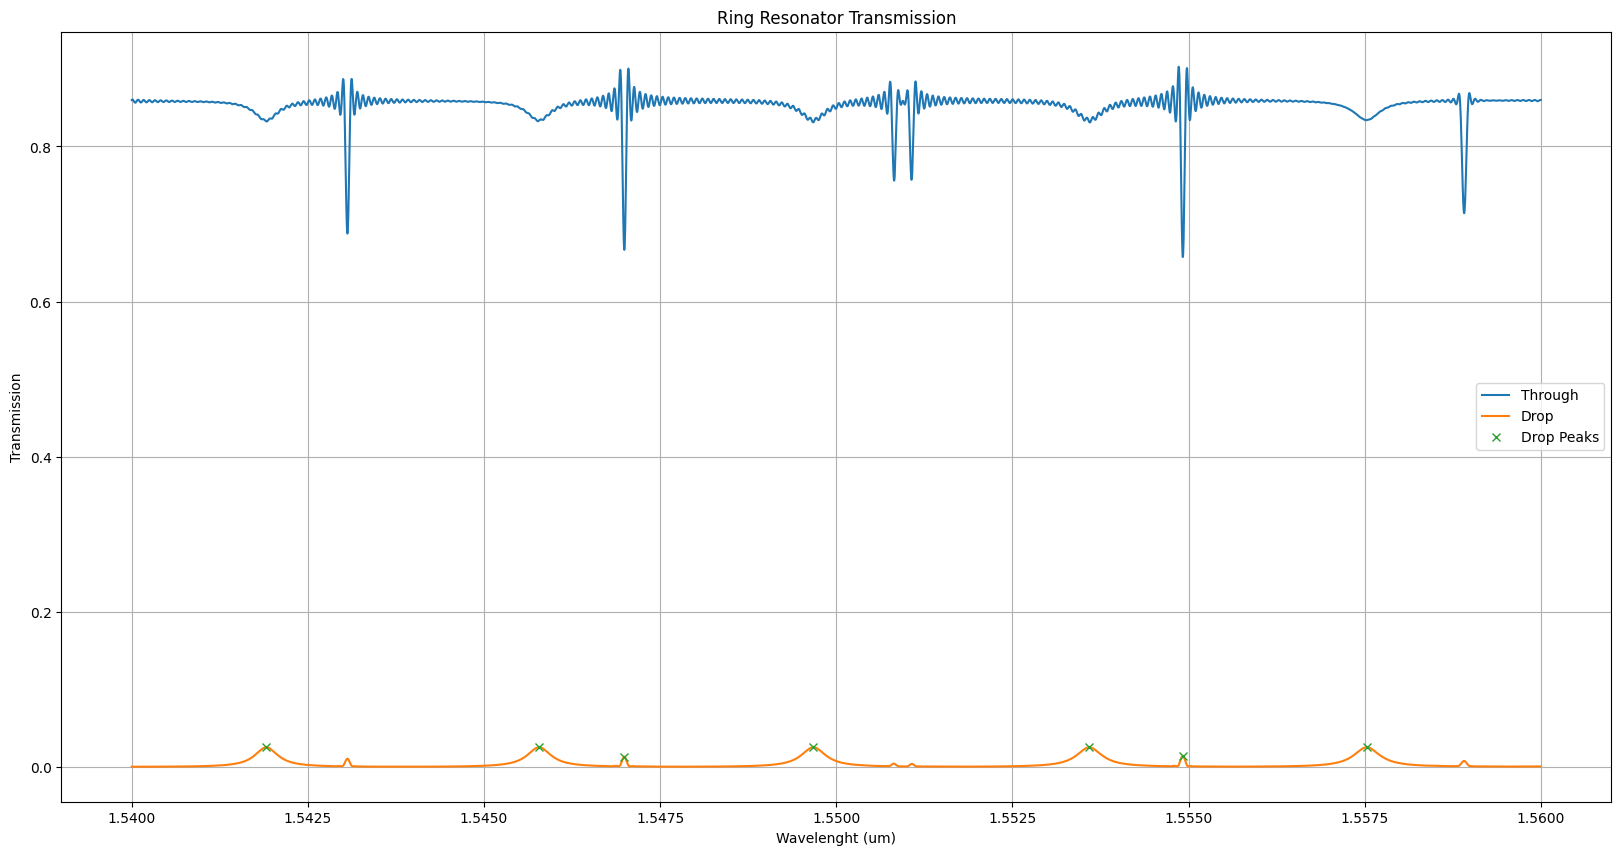

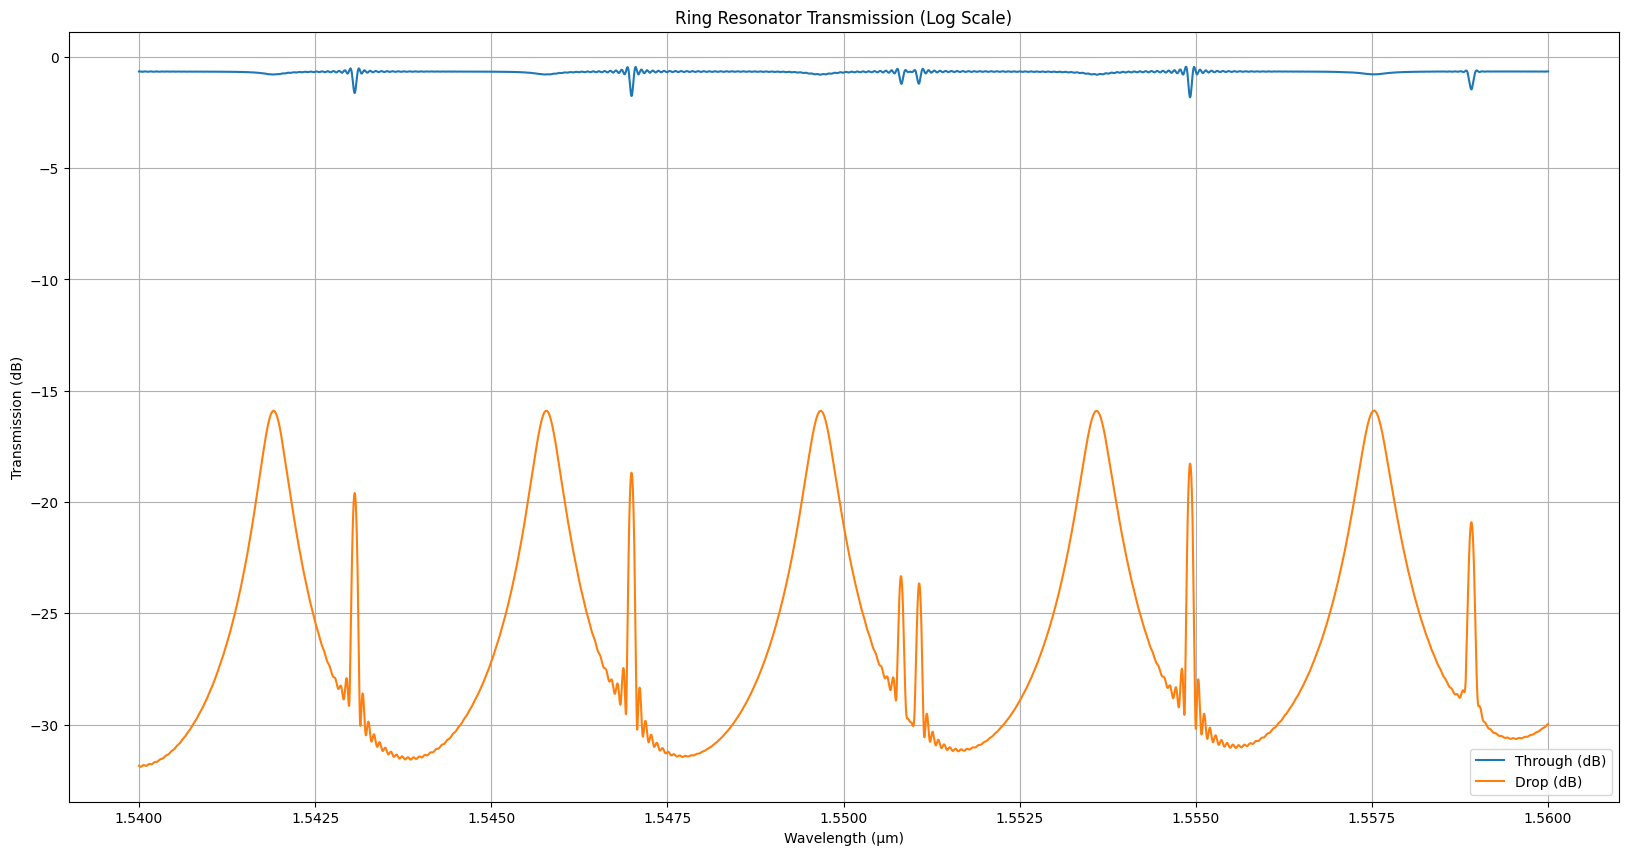

In [9]:
#------------------------------------------------------------
# Save Data
#------------------------------------------------------------
from scipy.signal import find_peaks

# GET RELEVENT RESULTS
T_through = f.getresult("Through","T")
T_drop    = f.getresult("Drop","T")

Transmission_through = T_through['T'].flatten()
Transmission_drop    = -T_drop['T'].flatten()
Wavelenghth          = T_through['lambda'].flatten()
print(f"Wavelength range: {(Wavelenghth[0])*1E9:.2f} nm to {(Wavelenghth[-1])*1E9:.2f} nm")

# --- FSR Calculation ---
# Find peaks in the drop port transmission
peaks, _ = find_peaks(Transmission_drop, height=0.5*np.max(Transmission_drop), distance=5)

peak_wavelengths = Wavelenghth[peaks]
if len(peak_wavelengths) >= 2:
	print("Peaks:", peak_wavelengths.flatten()*1e9)
	FSRs = np.abs(np.diff(peak_wavelengths.flatten()))
	avg_FSR = np.mean(FSRs)

# --- Loss and efficiency calculation at 1550 nm --------------------

eta_drop_1550 = Transmission_drop[np.argmin(np.abs(Wavelenghth - 1550E-9))]
eta_drop_1550 = max(eta_drop_1550, 1e-12)
if eta_drop_1550 < 1e-6:
	print("Warning: Drop efficiency at 1550 nm is extremely low, results may be inaccurate.")
elif eta_drop_1550 > 0.99:
	print("Warning: Drop efficiency at 1550 nm is extremely high, results may be inaccurate.")

loss_drop_1550_dB = -10 * np.log10(eta_drop_1550)

print(f"Summary of results at 1550 nm:")
print("-----------------------------------")
print(f"Drop Efficiency at 1550 nm: {eta_drop_1550*100:.2f} %")
print(f"Drop Loss at 1550 nm: {loss_drop_1550_dB:.2f} dB")


# -----------------------

plt.figure(figsize=(20,10))
plt.plot(Wavelenghth*1E6,Transmission_through, label='Through')
plt.plot(Wavelenghth*1E6,Transmission_drop, label='Drop')
plt.plot(Wavelenghth[peaks]*1E6, Transmission_drop[peaks], "x", label='Drop Peaks')
plt.xlabel("Wavelenght (um)")
plt.ylabel("Transmission")
plt.title("Ring Resonator Transmission")
plt.legend()
plt.grid()

# Log scale plot
plt.figure(figsize=(20,10))
plt.plot(Wavelenghth*1E6, 10*np.log10(Transmission_through), label='Through (dB)')
plt.plot(Wavelenghth*1E6, 10*np.log10(Transmission_drop),    label='Drop (dB)')
plt.xlabel("Wavelength (µm)")
plt.ylabel("Transmission (dB)")
plt.title("Ring Resonator Transmission (Log Scale)")
plt.legend()
plt.grid()


In [10]:
# --- Header (parse-friendly) ---
header = f"""Gap_nm={Gap*1e9:.2f}
WidthIO_nm={WidthIO*1e9:.2f}
Width_nm={Width*1e9:.2f}
Height_nm={Height*1e9:.2f}
CouplingLength_um={CouplingLength*1e6:.2f}
Radius_um={Radius*1e6:.2f}
Material={Material}
SimTime_ps={SimulationTime*1e12:.2f}
FrequencyPoints={FrequencyPoints}
LambdaStart_nm={LambdaStart*1e9:.2f}
LambdaStop_nm={LambdaStop*1e9:.2f}

M={M}

A_max_nm={A_max*1e9:.4f}

eta_drop_1550={eta_drop_1550:.6f}
loss_drop_1550_dB={loss_drop_1550_dB:.4f}

Wavelength_um\tTransmission_Through\tTransmission_Drop
"""

# --- Filename ---
filename = (
    f"Data_{LumFileName.removesuffix('.lms')}_pwsource_"
    f"Amax{A_max*1e9:.2f}nm_"
    f"M{M}_"
    f"LambdaRange{int(LambdaStart*1e9)}-{int(LambdaStop*1e9)}nm_"
    f"Gap{Gap*1e9:.0f}nm_Tx.txt"
)



# --- Data ---
data = np.column_stack((
    Wavelenghth * 1e6,   # um intentional
    Transmission_through,
    Transmission_drop
))

np.savetxt(
    DataDir / filename,
    data,
    delimiter='\t',
    header=header,
    comments='# ',      # explicit, MATLAB/Python friendly
    fmt='%.6e'
)

print(f"Data saved to {DataDir / filename }")


Data saved to D:\Ligentic_NU_1_TapeOut_April2026\scripts\RingMod_Squeezing\results_data\RingMOD_Ligentec_Results\Data_RingMOD_Ligentec_test_pwsource_Amax15.00nm_M[360]_LambdaRange1540-1560nm_Gap800nm_Tx.txt
